In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## Steps in PCA

1. Standardize the data (recommended)
    - Scale features so they have mean = 0 and standard deviation = 1.
    - This is important when features have different units or ranges.
2. Calculate the mean of each feature
    - Find the average value for every feature.
3. Center the data
    - Subtract the mean from each observation so that each feature has a mean of 0.
4. Calculate the covariance matrix
    - Measures how features vary together.
5. Calculate eigenvalues and eigenvectors
    - Eigenvectors determine the directions of the new feature space (principal components).
    - Eigenvalues indicate how much variance each principal component explains.
6. Choose the principal components
    - Rank components by eigenvalues (largest to smallest).
    - Select the top k components that explain most of the variance.
7. Project the data onto the selected principal components
    - Transform the original data into the new lower-dimensional space.

In [41]:
data = {
    'Size': [5, 3, 10, 2],
    'No of Rooms': [10, 7, 15, 4],
}

df = pd.DataFrame(data)
print("Original Data:\n", df)


Original Data:
    Size  No of Rooms
0     5           10
1     3            7
2    10           15
3     2            4


In [42]:
# Step 2: Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)
print("\nStandardized Data:\n", df_scaled)


Standardized Data:
        Size  No of Rooms
0  0.000000     0.246183
1 -0.648886    -0.492366
2  1.622214     1.477098
3 -0.973329    -1.230915


In [51]:
matrix1 = np.array(list(df_scaled['Size'] - df_scaled['Size'].mean())).reshape(-1,1)


In [52]:
matrix2 = np.array(list(df_scaled['No of Rooms'] - df_scaled['No of Rooms'].mean())).reshape(-1,1)


In [66]:
X = np.concatenate((matrix1, matrix2), axis=1).round(2)
X 

array([[ 0.  ,  0.25],
       [-0.65, -0.49],
       [ 1.62,  1.48],
       [-0.97, -1.23]])

In [67]:

X_trans = X.transpose()
X_trans

array([[ 0.  , -0.65,  1.62, -0.97],
       [ 0.25, -0.49,  1.48, -1.23]])

In [75]:
(1/3) * X_trans.dot(X)

array([[1.32926667, 1.30306667],
       [1.30306667, 1.3353    ]])

In [76]:
# Step 3: Compute Covariance Matrix
cov_matrix = np.cov(X.T)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[1.32926667 1.30306667]
 [1.30306667 1.33529167]]


In [77]:
# Step 4: Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [0.02920902 2.63534932]

Eigenvectors:
 [[-0.70792367 -0.70628895]
 [ 0.70628895 -0.70792367]]


In [78]:
# Step 5: Sort and Select Principal Components
explained_variance_ratio = eigenvalues / sum(eigenvalues)
print("\nExplained Variance Ratio:\n", explained_variance_ratio)

# Sort eigenvectors based on eigenvalues
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvectors = eigenvectors[:, sorted_index]

# Choose top 2 components
n_components = 2
eigenvector_subset = sorted_eigenvectors[:, 0:n_components]


Explained Variance Ratio:
 [0.01096205 0.98903795]


In [79]:
# Step 6: Transform the data
pca_data = np.dot(df_scaled, eigenvector_subset)

df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
print("\nTransformed Data (PCA Results):\n", df_pca)


Transformed Data (PCA Results):
         PC1       PC2
0 -0.174279  0.173876
1  0.806858  0.111609
2 -2.191425 -0.105146
3  1.558845 -0.180339


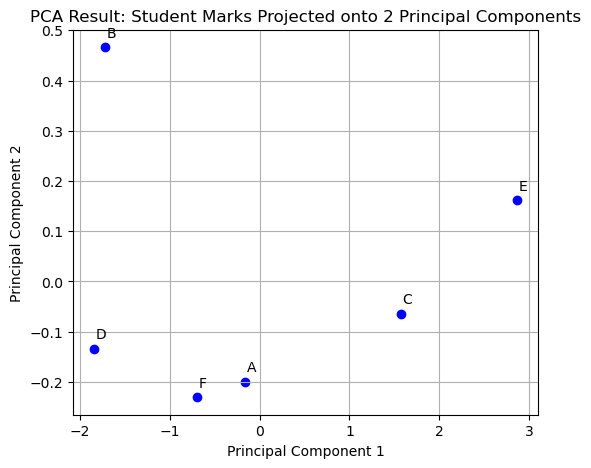

In [13]:
# Step 7: Plot the PCA results
plt.figure(figsize=(6, 5))
plt.scatter(df_pca['PC1'], df_pca['PC2'], color='blue')
plt.title('PCA Result: Student Marks Projected onto 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
for i, student in enumerate(['A', 'B', 'C', 'D', 'E', 'F']):
    plt.text(df_pca['PC1'][i]+0.02, df_pca['PC2'][i]+0.02, student)
plt.grid(True)
plt.show()

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

print("\nExplained Variance Ratio (Sklearn):", pca.explained_variance_ratio_)
print("\nPCA Components:\n", pca.components_)


Explained Variance Ratio (Sklearn): [0.97679943 0.01993008]

PCA Components:
 [[ 0.5790409   0.58058703  0.57239002]
 [-0.46806837 -0.33810496  0.81645394]]
